<a href="https://colab.research.google.com/github/swhoyle/electric-load-forecasting/blob/main/Electric_Load_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electric Load Forecasting

Spencer Hoyle  
UCSD DSE 260 - Spring 2026

Objective
---
Build a model to predict and forecast electric load.

We want to predict both short term (next minute to hour) and longer term (next day - 24 hours).

Dataset
---
A commercial business (Bakery) in Europe has provided 1-second power load data in Watts (W) recorded by electric meters in the business facilities.

- **Date range:**  11/28/2025 → 4/8/2026
- **Total days:**  132  
- **Shape:**      (11404800, 2)  

Each day has a work day classification label, provided by the customer:
- `full`: Full working day (both facility and bakery are open)
- `half`: Half working day (only facility is open; bakery is closed)
- `none`: Not a working day (both facility and bakery are closed)




## Imports

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from scipy.io import loadmat
from matplotlib.patches import Patch
from sklearn.metrics import mean_squared_error
from IPython.display import display
from google.colab import drive

plt.style.use("default")
color_palette = sns.color_palette()
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

Load raw data

In [119]:
raw_data = loadmat("/content/drive/MyDrive/ElectricLoadForecast/P_data.mat")
raw_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Apr 13 17:06:08 2026',
 '__version__': '1.0',
 '__globals__': [],
 'P_data': array([[1925., 1301., 1320., ..., 1380., 1400., 1280.],
        [1922., 1296., 1320., ..., 1388., 1400., 1264.],
        [1921., 1285., 1316., ..., 1386., 1398., 1267.],
        ...,
        [1253., 1315., 1518., ..., 1399., 1275., 2380.],
        [1248., 1315., 1506., ..., 1399., 1280., 2383.],
        [1249., 1317., 1516., ..., 1401., 1274., 2384.]]),
 'day_data': array([[array(['2025/11/28'], dtype='<U10'),
         array(['2025/11/29'], dtype='<U10'),
         array(['2025/11/30'], dtype='<U10'),
         array(['2025/12/01'], dtype='<U10'),
         array(['2025/12/02'], dtype='<U10'),
         array(['2025/12/03'], dtype='<U10'),
         array(['2025/12/04'], dtype='<U10'),
         array(['2025/12/05'], dtype='<U10'),
         array(['2025/12/06'], dtype='<U10'),
         array(['2025/12/07'], dtype='<U10'),
         array(['2025/12

In [120]:
raw_data["P_data"][0]

array([1925., 1301., 1320., 1496., 2568., 2574., 1629., 1852., 1549.,
       4226., 1624., 3286., 1645., 1289., 1442., 2285., 2357., 1055.,
       2255., 2043., 1318., 1735., 1455., 1812., 1151., 1137., 3991.,
       2403., 2123., 2606., 1318., 1462., 1861., 1776., 1746., 1780.,
       1167., 2516., 1635., 3744., 4473., 1949., 1763., 1793., 1601.,
       2445., 2243.,  656.,  723.,  441., 1860., 5409., 2286., 1423.,
       2272., 1196., 2433., 1478., 1839., 4977., 2227., 2516., 2033.,
       1769., 1524., 6609., 1904., 2150., 3681., 2711., 2106., 1686.,
        950., 1471., 2047., 1042., 6290., 1667., 1575., 5832., 1904.,
       1655., 2250., 3531., 3126.,  820.,  698., 1449., 2807.,  501.,
       1667., 3465., 1090.,  759.,  653.,  507.,  692., 1083., 5432.,
       1825., 1035., 1051., 2284., 1268., 8466., 1066., 1877., 2005.,
        922., 1974., 3319.,  645., 1187., 1258., 6033., 5225.,  423.,
       1223., 2551., 1900., 2276., 2838., 2556., 1953., 2394., 1541.,
       2265., 1095.,

In [121]:
p_data = raw_data["P_data"]
day_data = raw_data["day_data"]
day_class = raw_data["day_class"]

print("p_data shape:   ", p_data.shape)
print("day_data shape: ", day_data.shape)
print("day_class shape:", day_class.shape)

p_data shape:    (86400, 132)
day_data shape:  (1, 132)
day_class shape: (1, 132)


In [122]:
p_data

array([[1925., 1301., 1320., ..., 1380., 1400., 1280.],
       [1922., 1296., 1320., ..., 1388., 1400., 1264.],
       [1921., 1285., 1316., ..., 1386., 1398., 1267.],
       ...,
       [1253., 1315., 1518., ..., 1399., 1275., 2380.],
       [1248., 1315., 1506., ..., 1399., 1280., 2383.],
       [1249., 1317., 1516., ..., 1401., 1274., 2384.]])

Restructure raw data into data frame

In [123]:
columns = pd.to_datetime([d[0] for d in day_data.squeeze()])

df = (
    pd.DataFrame(p_data, columns=columns)
    .assign(second_of_day=np.arange(86400))
    .melt(id_vars="second_of_day", var_name="date", value_name="load")
    .assign(
        date=lambda x: pd.to_datetime(x["date"]),
        timestamp=lambda x: x["date"] + pd.to_timedelta(x["second_of_day"], unit="s")
    )
    .sort_values("timestamp")
    .reset_index(drop=True)
)

day_class_df = pd.DataFrame({
    "date": columns,
    "day_class": [d[0] for d in day_class.squeeze()]
})

df = df.merge(
    day_class_df,
    left_on=pd.to_datetime(df["timestamp"].dt.date),
    right_on="date",
    how="left"
)

df = df[["timestamp", "load", "day_class"]].set_index("timestamp")

print(df.shape)
df.head()

(11404800, 2)


,load,day_class
timestamp,,
2025-11-28 00:00:00,1925.0,full
2025-11-28 00:00:01,1922.0,full
2025-11-28 00:00:02,1921.0,full
2025-11-28 00:00:03,1921.0,full
2025-11-28 00:00:04,1926.0,full


## Exploratory Data Analysis

In [124]:
raw_df = df.copy()

In [125]:
print("Raw Data")
print("-------------------------")
print(f"Date range:  {raw_df.index.min()}  →  {raw_df.index.max()}")
print(f"Total days:  {raw_df.index.normalize().nunique()}")
print(f"Shape:       {raw_df.shape}")
print("-------------------------")
raw_df.head()

Raw Data
-------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:59:59
Total days:  132
Shape:       (11404800, 2)
-------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1925.0,full
2025-11-28 00:00:01,1922.0,full
2025-11-28 00:00:02,1921.0,full
2025-11-28 00:00:03,1921.0,full
2025-11-28 00:00:04,1926.0,full


### Downsample to 1 minute resolution

In [126]:
df = df.resample('1min').agg({'load': 'mean', 'day_class': 'first'})

print("Resampled Data (1 min)")
print("-------------------------")
print(f"Date range:  {df.index.min()}  →  {df.index.max()}")
print(f"Total days:  {df.index.normalize().nunique()}")
print(f"Shape:       {df.shape}")
print("-------------------------")
df.head()

Resampled Data (1 min)
-------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:59:00
Total days:  132
Shape:       (190080, 2)
-------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1912.400000,full
2025-11-28 00:01:00,1908.233333,full
2025-11-28 00:02:00,1643.183333,full
2025-11-28 00:03:00,2992.950000,full
2025-11-28 00:04:00,1106.000000,full


### Missing Values

In [127]:
print(f"Missing values (raw 1-second resolution):")
print("-------------------------")
total = len(raw_df)
missing = raw_df.isnull().sum()
pct = ((missing / total) * 100).round(2)
print(pd.DataFrame({'missing': missing, '%': pct}))
print("-------------------------")

print(f"\nMissing values (1-minute resolution):")
print("-------------------------")
total = len(df)
missing = df.isnull().sum()
pct = ((missing / total) * 100).round(2)
print(pd.DataFrame({'missing': missing, '%': pct}))
print("-------------------------")

Missing values (raw 1-second resolution):
-------------------------
           missing    %
load         46099  0.4
day_class        0  0.0
-------------------------

Missing values (1-minute resolution):
-------------------------
           missing     %
load            74  0.04
day_class        0  0.00
-------------------------


### Zero Load

In [128]:
print("Negative Load Values (raw 1-second resolution):")
print("-------------------------")
total = len(raw_df)
zero = raw_df[raw_df['load'] == 0].shape[0]
pct = round((zero / total) * 100, 2)
print(pd.DataFrame({'count': [zero], '%': [pct]}))
print("-------------------------")

print("\nNegative Load Values (1-minute resolution):")
print("-------------------------")
total = len(df)
zero = df[df['load']  == 0].shape[0]
pct = round((zero / total) * 100, 2)
print(pd.DataFrame({'count': [zero], '%': [pct]}))
print("-------------------------")

Negative Load Values (raw 1-second resolution):
-------------------------
   count    %
0    261  0.0
-------------------------

Negative Load Values (1-minute resolution):
-------------------------
   count    %
0      0  0.0
-------------------------


### Negative Load

In [129]:
print("Negative Load Values (raw 1-second resolution):")
print("-------------------------")
total = len(raw_df)
negative = raw_df[raw_df['load'] < 0].shape[0]
pct = round((negative / total) * 100, 2)
print(pd.DataFrame({'count': [negative], '%': [pct]}))
print("-------------------------")

print("\nNegative Load Values (1-minute resolution):")
print("-------------------------")
total = len(df)
negative = df[df['load'] < 0].shape[0]
pct = round((negative / total) * 100, 2)
print(pd.DataFrame({'count': [negative], '%': [pct]}))
print("-------------------------")

Negative Load Values (raw 1-second resolution):
-------------------------
    count     %
0  703079  6.16
-------------------------

Negative Load Values (1-minute resolution):
-------------------------
   count     %
0  11340  5.97
-------------------------


### Full time-series Plot

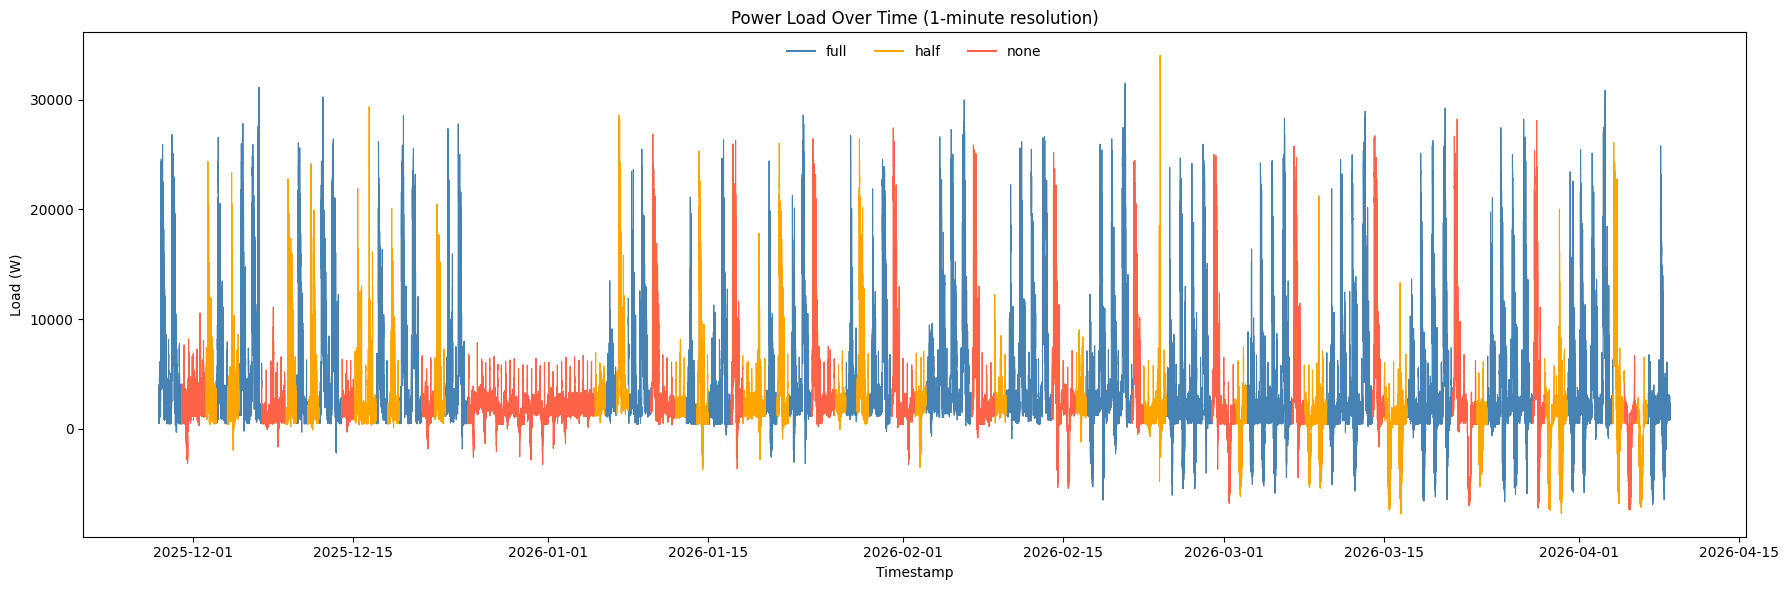

In [130]:
color_map = {'full': 'steelblue', 'half': 'orange', 'none': 'tomato'}

plt.figure(figsize=(18, 6))
for cls in color_map:
    masked = df['load'].copy()
    masked[df['day_class'] != cls] = np.nan
    plt.plot(masked.index, masked, color=color_map[cls], linewidth=0.8, label=cls)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=color_map[cls], label=cls) for cls in color_map]
plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.title("Power Load Over Time (1-minute resolution)")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

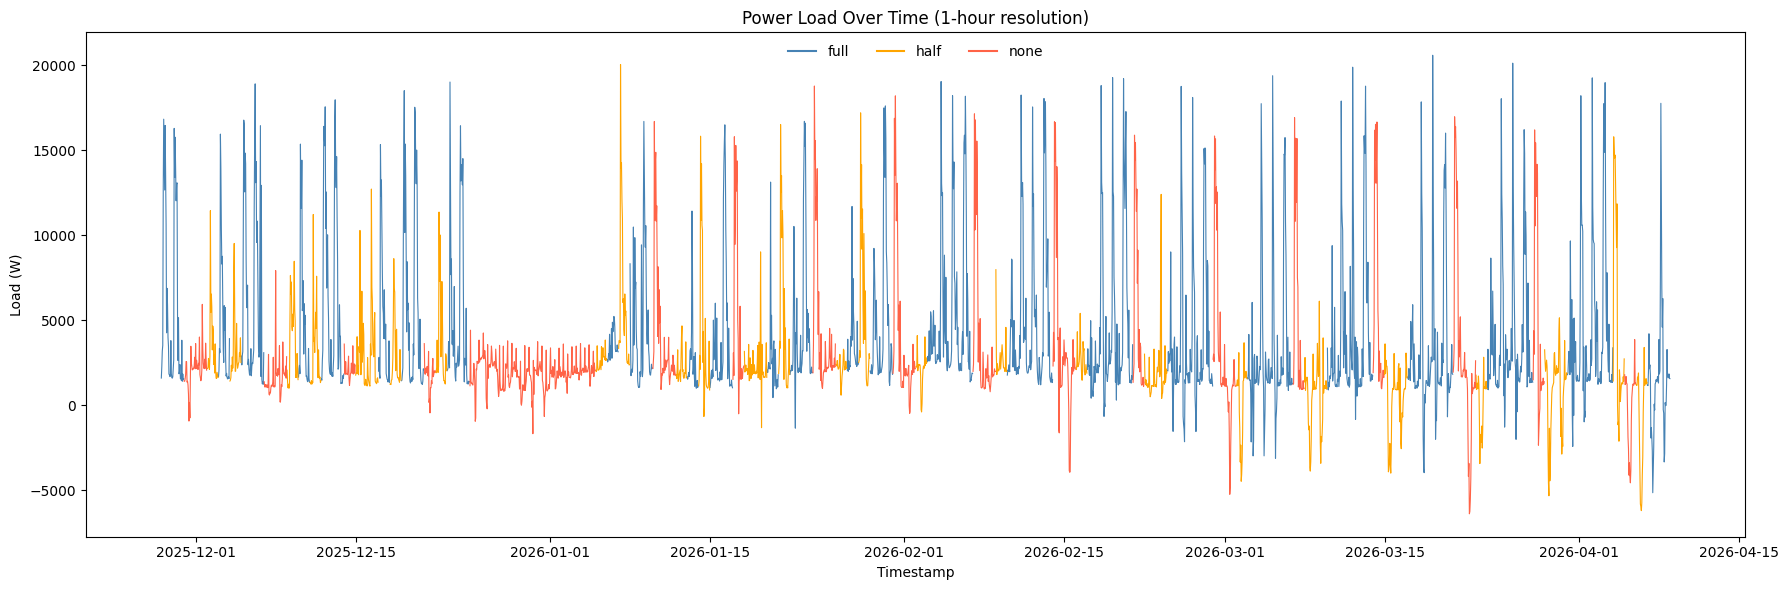

In [131]:
color_map = {'full': 'steelblue', 'half': 'orange', 'none': 'tomato'}

df_1h = df.resample('1h').agg({'load': 'mean', 'day_class': 'first'})

plt.figure(figsize=(18, 6))
for cls in color_map:
    masked = df_1h['load'].copy()
    masked[df_1h['day_class'] != cls] = np.nan
    plt.plot(masked.index, masked, color=color_map[cls], linewidth=0.8, label=cls)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=color_map[cls], label=cls) for cls in color_map]
plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.title("Power Load Over Time (1-hour resolution)")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

### Single-Day Load Plot

In [132]:
dates = df.index.normalize().unique().sort_values()
daily_summary = df.groupby(df.index.normalize()).agg(
    day_class=('day_class', 'first'),
    avg_load=('load', 'mean')
)

options = [
    f"{d.strftime('%Y-%m-%d')} ({daily_summary.loc[d, 'day_class']}) ({daily_summary.loc[d, 'avg_load']:.0f}W avg)"
    for d in dates
]

dropdown = widgets.Dropdown(options=options, description='Date:')

def plot_day(option):
    date = option.split(' ')[0]
    cls = option.split('(')[1].rstrip(') ')
    data = df.loc[date]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(data.index, data['load'], color=color_map[cls], linewidth=0.8)
    ax.set_title(f"Power Load — {option}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Load (W)")
    plt.tight_layout()
    plt.show()

widgets.interact(plot_day, option=dropdown)

interactive(children=(Dropdown(description='Date:', options=('2025-11-28 (full) (6201W avg)', '2025-11-29 (ful…

<function __main__.plot_day(option)>

### Load Distribution

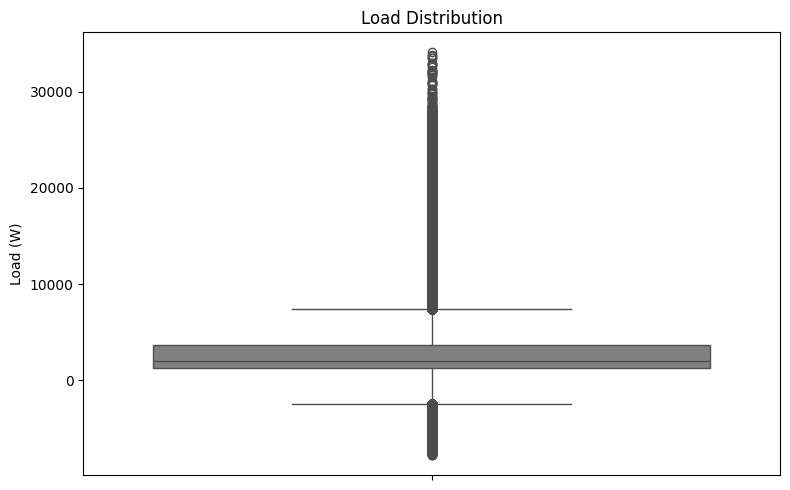

Load Stats:


,count,mean,std,min,25%,50%,75%,max
load,190006.0,3511.08,4722.73,-7742.17,1265.94,2035.79,3726.95,34057.93


In [133]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y='load', color='grey')
plt.title("Load Distribution")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

print("Load Stats:")
display(df['load'].describe().round(2).to_frame().T)

### Load Distibution (day class)

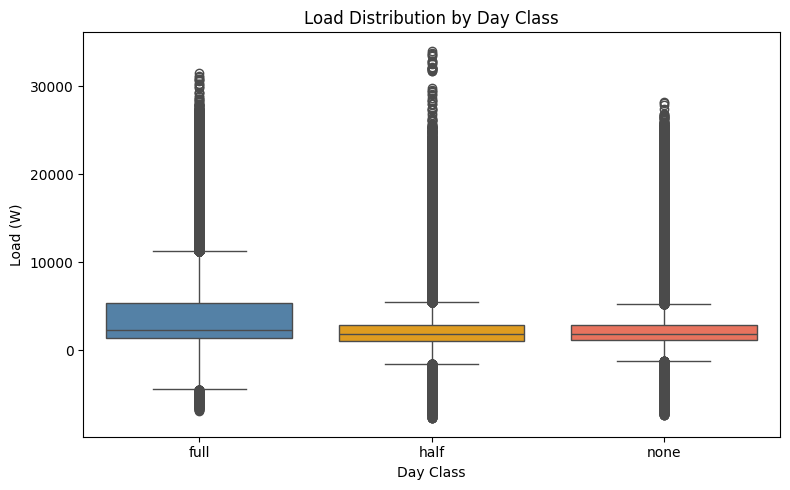


Load Stats By Class:


,count,mean,std,min,25%,50%,75%,max
day_class,,,,,,,,
full,90669.0,4372.72,5263.11,-6894.20,1423.88,2337.45,5350.23,31515.92
half,46058.0,2419.89,3656.85,-7742.17,1066.12,1810.54,2828.93,34057.93
none,53279.0,2988.07,4275.11,-7387.52,1195.92,1866.52,2831.40,28240.05


In [134]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='day_class', y='load', hue='day_class', palette=color_map,
            order=['full', 'half', 'none'], legend=False)
plt.title("Load Distribution by Day Class")
plt.xlabel("Day Class")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

print("\nLoad Stats By Class:")
display(df.groupby('day_class')['load'].describe().round(2))

### Load Distribution (monthly)

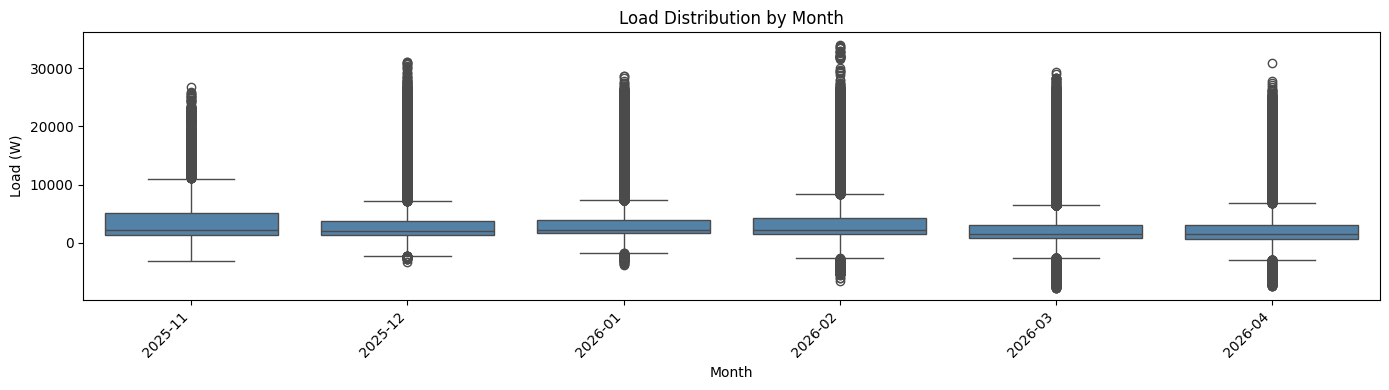

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
2025-11,4319.0,4539.46,5408.05,-3156.72,1281.70,2257.82,5187.62,26838.28
2025-12,44601.0,3584.11,4267.97,-3254.73,1345.05,2063.42,3705.00,31137.08
2026-01,44639.0,3815.12,4242.19,-3740.50,1633.62,2286.30,3915.40,28626.30
2026-02,40306.0,4023.51,4944.10,-6496.05,1480.21,2264.73,4256.33,34057.93
2026-03,44627.0,2765.74,4977.96,-7742.17,761.02,1560.60,3031.43,29257.95
2026-04,11514.0,2758.79,5545.13,-7387.52,702.09,1497.47,3139.00,30861.03


In [135]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x=df.index.to_period('M').astype(str), y='load', color='steelblue')
plt.title("Load Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Load (W)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(df.groupby(df.index.to_period('M'))['load'].describe().round(2))

### Load Distribution (daily)

In [ ]:
plt.figure(figsize=(25, 5))
sns.boxplot(data=df, x=df.index.normalize(), y='load',
            hue=df['day_class'], palette=color_map, legend=False)
plt.title("Daily Load Distribution")
plt.xlabel("Date")
plt.ylabel("Load (W)")
plt.xticks(rotation=45, ha='right')

handles = [Patch(facecolor=color_map[cls], label=cls) for cls in color_map]
plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.tight_layout()
plt.show()

display(df.groupby(df.index.normalize())['load'].describe().round(2))

### Load Distribution (day of week)

In [ ]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x=df.index.day_name(), y='load', order=days_order, color='steelblue')
plt.title("Load Distribution by Day of Week")
plt.xlabel("")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

display(df.groupby(df.index.day_name())['load'].describe().round(2).reindex(days_order))

### Load Distribution (hour)

In [ ]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x=df.index.hour, y='load', color='steelblue')
plt.title("Load Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

display(df.groupby(df.index.hour)['load'].describe().round(2))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, cls in zip(axes, ['full', 'half', 'none']):
    mask = df['day_class'] == cls
    sns.boxplot(data=df[mask], x=df[mask].index.hour, y='load',
                color=color_map[cls], ax=ax)
    ax.set_title(f"Load by Hour — {cls}")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Load (W)" if ax == axes[0] else "")

plt.tight_layout()
plt.show()

for cls in ['full', 'half', 'none']:
    mask = df['day_class'] == cls
    print(f"\n{cls}:")
    display(df[mask].groupby(df[mask].index.hour)['load'].describe().round(2))

## Train/ Test Split

Use the final 20% of days as the test set, with the remainder used for training.

In [ ]:
def train_test_split(df, test_size=0.2):
  """Train/Test split by percent of days"""
  n_days = df.index.normalize().nunique()
  n_test = int(np.ceil(n_days * 0.2))
  split_date = df.index.normalize().unique().sort_values()[-n_test]

  train = df.loc[:split_date]
  test  = df.loc[split_date:]
  return train, test

train, test = train_test_split(df)

print(f"Train: {train.index.min().date()} → {train.index.max().date()} ({train.index.normalize().nunique()} days)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()} ({test.index.normalize().nunique()} days)")

plt.figure(figsize=(14, 4))
plt.plot(train.resample('1min')['load'].mean(), color='steelblue', linewidth=0.8, label='Train')
plt.plot(test.resample('1min')['load'].mean(), color='tomato', linewidth=0.8, label='Test')
plt.axvline(train.index.max(), color='black', linestyle='--', linewidth=1)
plt.title("Train / Test Split")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.tight_layout()
plt.show()

print("Train Data:")
print(train.shape)
display(train.head(3))

print("\nTest Data:")
print(test.shape)
display(test.head(3))

Ensure all day classifications are being tested

In [ ]:
print("Test Set Day Class Distribution:")
test_dist = test.groupby(test.index.normalize())['day_class'].first().value_counts()
test_pct  = (test_dist / test_dist.sum() * 100).round(1)
display(pd.DataFrame({'days': test_dist, '%': test_pct}))

## Feature Engineering

In [ ]:
def create_features(df):
    df = df.copy()

    # Time features
    df['second']      = df.index.second
    df['minute']      = df.index.minute
    df['hour']        = df.index.hour
    df['dayofweek']   = df.index.dayofweek
    df['month']       = df.index.month
    df['year']        = df.index.year
    df['dayofyear']   = df.index.dayofyear
    df['weekend']     = (df['dayofweek'] > 4).astype(int)

    # Cyclical encoding
    df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']     = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']     = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)

    # Lag features (in seconds)
    df['lag_1min']    = df['load'].shift(60)
    df['lag_5min']    = df['load'].shift(300)
    df['lag_30min']   = df['load'].shift(1800)
    df['lag_1day']    = df['load'].shift(86400)
    df['lag_1week']   = df['load'].shift(604800)

    # Rolling features
    df['roll_mean_5min']  = df['load'].shift(1).rolling(300).mean()
    df['roll_std_5min']   = df['load'].shift(1).rolling(300).std()
    df['roll_mean_30min'] = df['load'].shift(1).rolling(1800).mean()
    df['roll_std_30min']  = df['load'].shift(1).rolling(1800).std()
    df['roll_max_30min']  = df['load'].shift(1).rolling(1800).max()
    df['roll_min_30min']  = df['load'].shift(1).rolling(1800).min()

    # Day class one-hot encoding
    df = pd.get_dummies(df, columns=['day_class'], prefix='day_class')

    return df

df_features = df.dropna(subset=['load'])
df_features = create_features(df_features)
df_features.head()

## Modeling

### XG Boost

Preprocessing

In [ ]:
FEATURES = ['day_class_full', 'day_class_none', 'day_class_half', 'minute', 'hour', 'dayofweek', 'month', 'year','dayofyear', 'weekend']
TARGET = 'load'
FEATURES = [c for c in df_features.columns if c != TARGET]

train, test = train_test_split(df_features)

X_train = train[FEATURES]
X_test = test[FEATURES]

y_train = train[TARGET]
y_test = test[TARGET]

Train

In [ ]:
import xgboost as xgb
reg = xgb.XGBRegressor(n_estimators = 10000,early_stopping_rounds=50, learning_rate=0.01)
reg.fit(X_train, y_train, eval_set = [(X_train, y_train), (X_test, y_test)],verbose=100)

Feature Importance

In [ ]:
fi = pd.DataFrame(data=reg.feature_importances_, index = reg.feature_names_in_, columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')

Forecast

In [ ]:
y_pred = reg.predict(X_test)
y_pred

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Model Evaluation:")
display(pd.DataFrame({
    'MAE':  [round(mae, 2)],
    'RMSE': [round(rmse, 2)]
}))

plt.figure(figsize=(18, 4))
plt.plot(y_test.index, y_test.values, color='steelblue', linewidth=0.8, label='Actual')
plt.plot(y_test.index, y_pred, color='tomato', linewidth=0.8, label='Predicted')
plt.title("Actual vs Predicted Load")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.legend()
plt.tight_layout()
plt.show()

Error


In [ ]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby('date')['error'].mean().plot(kind='barh')